In [37]:
# import libraries
import os
import pandas as pd
from datetime import datetime

In [38]:
# view all files in the folder

ftw_apeq = input()

folder_path = rf"C:/Users/luke.roberts/OneDrive - ASICS Corporation/Documents/vs_code/input/{ftw_apeq}"

excel_files = [f for f in os.listdir(folder_path) if f.endswith('.xlsx')] # list of all files in the folder
excel_files

['SS26 APEQ MF3 -- Forecasting -- ALS.xlsx',
 'SS26 APEQ MF3 -- Forecasting -- INX.xlsx',
 'SS26 APEQ MF3 -- Forecasting -- KEY.xlsx',
 'SS26 APEQ MF3 -- Forecasting -- MAP.xlsx',
 'SS26 APEQ MF3 -- Forecasting -- MNT.xlsx']

In [39]:
# store dfs
# create a dictionary to store dataframes
dataframes = {}

# import each file as its own dataframe variable and save in the dictionary

# loop through each file and import the specific sheet
for file in excel_files:
    file_name = file.split("--")[-1].replace(".xlsx", "").strip() # splits the file after"--" to use as name
    file_path = os.path.join(folder_path, file)
    try:
        dataframes[file_name] = pd.read_excel(file_path, sheet_name="ASSORTMENT") # import assortment sheet
        print(f"imported {file_name}") # print the file name and path
    except PermissionError as e:
        print(f"PermissionError: Could not open {file_path}. Please close the file if it is open in another program.")
    except Exception as e:
        print(f"Error importing {file_name}: {e}")


imported ALS
imported INX
imported KEY
imported MAP
imported MNT


In [40]:

# checkpoint 1
print(f"checkpoint 1: all excel files loaded")

checkpoint 1: all excel files loaded


In [41]:
# rename dfs to their key
for key, df in dataframes.items():
    globals()[key] = df

for key in dataframes.keys():
    df = dataframes[key]
    print(f"DataFrame name: {key}")
    print(df.head(10))
    print("-_"*50)


DataFrame name: ALS
          1013A127-300       dropped Unnamed: 2 Unnamed: 3  \
0                  NaN           NaN        NaN        NaN   
1                  NaN           NaN        NaN        NaN   
2                  NaN           NaN        NaN        NaN   
3                  NaN           NaN        NaN        NaN   
4                  NaN           NaN        NaN        NaN   
5                  NaN           NaN        NaN        NaN   
6                  NaN           NaN        NaN        NaN   
7  CATEGORY IDENTIFIER    ITEM COLOR     SEASON      BRAND   
8       SS26RUNAPEQ001  2012D351-100       SS26      ASICS   
9       SS26RUNAPEQ002  2011D434-001       SS26      ASICS   

            Unnamed: 4     Unnamed: 5 Unnamed: 6 Unnamed: 7 Unnamed: 8  \
0                  NaN            NaN        NaN        NaN        NaN   
1                  NaN            NaN        NaN        NaN        NaN   
2                  NaN            NaN        NaN        NaN        NaN   
3

In [42]:
# view the current working dfs
working_dfs = list(dataframes.keys())
working_dfs

['ALS', 'INX', 'KEY', 'MAP', 'MNT']

In [43]:
# Drop rows where column 1 ("Unnamed: 1") is empty (NaN) for each dataframe
for df in list(dataframes.values()):
    df.dropna(subset=[df.columns[0]], inplace=True)
    df.reset_index(drop=True, inplace=True)

In [44]:
# check top two rows
for name in working_dfs:
    df = globals()[name]
    print(f"{name}:\n{df.head(2)}\n")

ALS:
          1013A127-300       dropped Unnamed: 2 Unnamed: 3  \
0  CATEGORY IDENTIFIER    ITEM COLOR     SEASON      BRAND   
1       SS26RUNAPEQ001  2012D351-100       SS26      ASICS   

            Unnamed: 4     Unnamed: 5 Unnamed: 6 Unnamed: 7 Unnamed: 8  \
0             DIVISION  PRODUCT GROUP   CATEGORY      SUB 1     SUB 2    
1  PERFORMANCE RUNNING        APPAREL    RUNNING     JACKET       BEST   

       Unnamed: 9  ... Unnamed: 31 Unnamed: 32  \
0  ARTICLE FAMILY  ...    FUNCTION    EMEA RPR   
1         METARUN  ...         NaN         NaN   

                                Unnamed: 33          Unnamed: 34  \
0                   MERCHANDISING DIRECTION  2026-01-01 00:00:00   
1  LIMITED EDITION \n= H2T MANDATORY\n(DTC)                  NaN   

           Unnamed: 35          Unnamed: 36          Unnamed: 37  \
0  2026-02-01 00:00:00  2026-03-01 00:00:00  2026-04-01 00:00:00   
1                  NaN                  NaN                  NaN   

           Unnamed: 38  

In [45]:
# set first row as header for each dataframe and reset index
for name in working_dfs:
    df = globals()[name]
    df.columns = df.iloc[0]
    globals()[name] = df[1:].reset_index(drop=True)

In [46]:
# print shape of each dataframe
for name in working_dfs:
    df = globals()[name]
    print(f"shape {name}: {df.shape}")
    print("-_"*50)

# print 2 rows and 4 columns of each dataframe
for name in working_dfs:
    df = globals()[name]
    print(f"{name}")
    print(df.iloc[:2, :4])
    print("-_"*50)

shape ALS: (559, 41)
-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_
shape INX: (524, 41)
-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_
shape KEY: (559, 41)
-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_
shape MAP: (559, 41)
-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_
shape MNT: (559, 41)
-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_
ALS
0 CATEGORY IDENTIFIER    ITEM COLOR SEASON  BRAND
0      SS26RUNAPEQ001  2012D351-100   SS26  ASICS
1      SS26RUNAPEQ002  2011D434-001   SS26  ASICS
-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_
INX
0 CATEGORY IDENTIFIER    ITEM COLOR SEASON  BRAND
0      SS26RUNAPEQ001  2012D351-100   SS26  ASICS
1      SS26RUNAPEQ002  2011D434

In [47]:
# checkpoint 2
print("checkpoint 2: rows dropped, and column headers set")

checkpoint 2: rows dropped, and column headers set


In [48]:
# add a new column to each dataframe with dataframe name set to each row
for name in working_dfs:
    df = globals()[name]
    df['DIS'] = name  # Add a new column named 'DIS' with the dataframe name
    globals()[name] = df  # Update the global variable

In [49]:
# print shape of each dataframe
for name in working_dfs:
    df = globals()[name]
    print(f"shape {name}: {df.shape}")
    print("-_"*50)

# print 2 rows and last 2 columns of each dataframe
for name in working_dfs:
    df = globals()[name]
    print(f"{name}")
    print(df.iloc[:2, -2:])
    print("-_"*50)

shape ALS: (559, 42)
-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_
shape INX: (524, 42)
-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_
shape KEY: (559, 42)
-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_
shape MAP: (559, 42)
-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_
shape MNT: (559, 42)
-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_
ALS
0 Total   DIS
0      0  ALS
1      0  ALS
-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_
INX
0 Total   DIS
0      0  INX
1      0  INX
-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_
KEY
0 Total   DIS
0     20  KEY
1     24  KEY
-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_

In [50]:
# checkpoint 4
print("checkpoint 4: dfs")

checkpoint 4: dfs


In [51]:
working_dfs

['ALS', 'INX', 'KEY', 'MAP', 'MNT']

In [52]:
# Concatenate all dataframes in working_dfs vertically
dis_consolidated = pd.concat([globals()[name] for name in working_dfs], ignore_index=True)
print(f"Shape of concatenated dataframe: {dis_consolidated.shape}")
print(dis_consolidated.head())


Shape of concatenated dataframe: (2760, 42)
0 CATEGORY IDENTIFIER    ITEM COLOR SEASON  BRAND             DIVISION  \
0      SS26RUNAPEQ001  2012D351-100   SS26  ASICS  PERFORMANCE RUNNING   
1      SS26RUNAPEQ002  2011D434-001   SS26  ASICS  PERFORMANCE RUNNING   
2      SS26RUNAPEQ003  2012D421-100   SS26  ASICS  PERFORMANCE RUNNING   
3      SS26RUNAPEQ004  2011D513-001   SS26  ASICS  PERFORMANCE RUNNING   
4      SS26RUNAPEQ005  2012D415-001   SS26  ASICS  PERFORMANCE RUNNING   

0 PRODUCT GROUP CATEGORY           SUB 1 SUB 2  ARTICLE FAMILY  ... EMEA RPR  \
0       APPAREL  RUNNING          JACKET   BEST        METARUN  ...      NaN   
1       APPAREL  RUNNING          JACKET   BEST        METARUN  ...      NaN   
2       APPAREL  RUNNING  SLEEVELESS TOP   BEST        METARUN  ...      NaN   
3       APPAREL  RUNNING          SS TOP   BEST        METARUN  ...      NaN   
4       APPAREL  RUNNING           SHORT   BEST        METARUN  ...      NaN   

0                   MERCHANDIS

In [53]:
dis_consolidated.iloc[2]

0
CATEGORY IDENTIFIER                                           SS26RUNAPEQ003
ITEM COLOR                                                      2012D421-100
SEASON                                                                  SS26
BRAND                                                                  ASICS
DIVISION                                                 PERFORMANCE RUNNING
PRODUCT GROUP                                                        APPAREL
CATEGORY                                                             RUNNING
SUB 1                                                         SLEEVELESS TOP
SUB 2                                                                   BEST
ARTICLE FAMILY                                                       METARUN
COLLECTION TYPE                                                       INLINE
ITEM TYPE                                                                NEW
GENDER                                                                 WOM

In [54]:
# Use .count() instead of .counts() to get the count of non-NA cells for each column per group
dis_consolidated.groupby('DIS')['DIS'].count()

DIS
ALS    559
INX    524
KEY    559
MAP    559
MNT    559
Name: DIS, dtype: int64

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='DIS', ylabel='Count'>

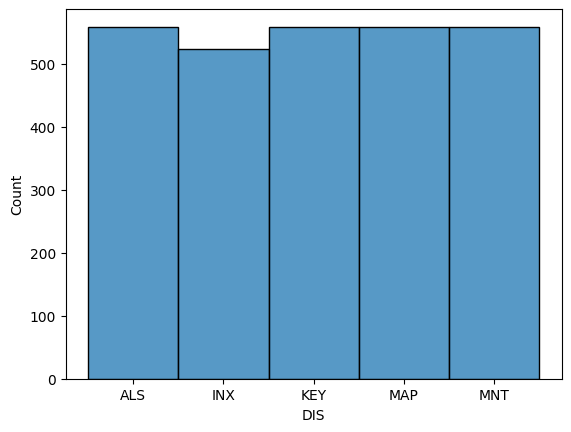

In [56]:
# histogram of distributor rows in consolidation
sns.histplot(dis_consolidated['DIS'])

In [57]:
# enter season
print("enter file export name, eg SS26_FTW_MF2:")
season = input(f"file name: {str()}")

enter file export name, eg SS26_FTW_MF2:


In [ ]:
# export dis_stacked as excel file
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M")
output_file = f"C:/Users/luke.roberts/OneDrive - ASICS Corporation/Documents/vs_code/output/dis_consolidated_{season}_{timestamp}.xlsx"
dis_consolidated.to_excel(output_file, index=False)

print(f"checkpoint 5: export to excel successful, saved as {output_file}")

checkpoint 5: export to excel successful, saved as C:/Users/luke.roberts/OneDrive - ASICS Corporation/Documents/vs_code/output/dis_consolidated_apeq_2025-05-28_16-41.xlsx
